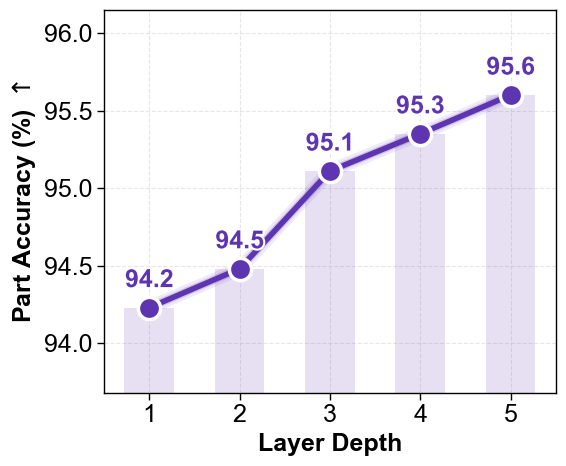

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# ==========================================
# 🎯 [USER CONFIGURATION] Layer Ablation (PA Only)
# ==========================================
FIG_WIDTH = 6.0   
FIG_HEIGHT = 5.0

# 더 진하고 고급스러운 보라색(Deep Purple)
COLOR_CKA = '#5E35B1'  

plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'font.family': 'Arial', 
    'axes.facecolor': '#FFFFFF', 
    'figure.facecolor': 'white',
})

# 데이터 읽기
df_ablation = pd.read_csv('layer_ablation.csv')

# Baseline ('None') 제외하고 Layer 번호가 있는 행만 추출
layer_rows = df_ablation[df_ablation['Layer'].notna()].copy()
layers = layer_rows['Layer'].astype(int).values
pa_vals = layer_rows['PA'].values
# ==========================================

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# 💡 0. Y축의 하단 여백 한계값(bottom_y) 계산
y_min = min(pa_vals)
y_max = max(pa_vals)
y_range = y_max - y_min
bottom_y = y_min - y_range*0.4

# 💡 1. 연한 보라색(alpha=0.15) 바 플롯 그리기
# 화면 밖으로 넘치지 않게 bottom_y 부터 시작하도록 높이를 조절
ax.bar(layers, pa_vals - bottom_y, bottom=bottom_y, width=0.55, 
       color=COLOR_CKA, alpha=0.15, zorder=2, edgecolor='none')

# 2. CKA (Ours) 꺾은선 그리기 (Glow Effect)
for lw, alpha in zip([10, 6], [0.1, 0.2]):
    ax.plot(layers, pa_vals, color=COLOR_CKA, linewidth=lw, alpha=alpha, zorder=4)

# 3. 메인 꺾은선 및 대형 마커
ax.plot(layers, pa_vals, marker='o', markersize=16, markeredgecolor='white', markeredgewidth=2.5, 
        color=COLOR_CKA, linewidth=4.0, zorder=5, label='CKA (Ours)')

# 4. 각 점 위에 실제 성능 숫자 달아주기 (흰색 테두리 적용)
for l, p in zip(layers, pa_vals):
    ax.text(l, p + 0.1, f"{p:.1f}", color=COLOR_CKA, fontweight='bold', ha='center', va='bottom',
            path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=10)

# 5. 축 및 라벨 스타일링
# ax.set_title('Ablation on Alignment Layer', fontweight='heavy', pad=15, color='black')
ax.set_xlabel('Layer Depth', fontweight='bold', color='black') # (기존 요청에 따라 생략)
ax.set_ylabel(r'Part Accuracy (%) $\uparrow$', fontweight='bold', color='black')

ax.set_xticks(layers)
ax.set_xticklabels([f"{l}" for l in layers])

# 6. 4면 검정색 테두리 설정
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax.tick_params(axis='both', colors='black', width=1.0, length=5)
ax.grid(True, linestyle='--', color='#E0E0E0', alpha=0.8, zorder=0)

# 7. Y축 여백 설정
ax.set_ylim(bottom_y, y_max + y_range*0.4)

plt.tight_layout()
plt.savefig('layer_ablation.pdf', bbox_inches='tight')
plt.show()